# PCA From Scratch

Use covariance eigenvectors to compress two features into one direction.

## What to look for

The long axis shows the main direction; projecting onto it reduces two dimensions to one.

This notebook uses the same small example as `main.py`. The chart preview below is embedded so it appears as soon as you open the notebook. Run the code cell to recalculate the printed results and interactive Matplotlib figure (requires NumPy and Matplotlib).


In [ ]:
"""Two-feature PCA using covariance and eigenvectors."""
import numpy as np
import matplotlib.pyplot as plt
# The matrix mixes two random measurements to create correlated features.
rng=np.random.default_rng(3); data=rng.normal(size=(60,2))@np.array([[2,1.4],[.2,.5]]); data[:,0]+=5
center=data.mean(axis=0); centered=data-center
# eigh returns covariance eigenvectors; sorting by eigenvalue puts the most variable direction first.
values,vectors=np.linalg.eigh(np.cov(centered,rowvar=False)); order=np.argsort(values)[::-1]; values=values[order]; vectors=vectors[:,order]
# Project each centered point onto the first principal direction.
projected=centered@vectors[:,:1]; reconstructed=projected@vectors[:,:1].T+center
print("Eigenvalues:",np.round(values,2)); print(f"Variance kept: {values[0]/values.sum():.1%}")
plt.scatter(data[:,0],data[:,1],alpha=.65,label="original points")
plt.plot([center[0]-3*vectors[0,0],center[0]+3*vectors[0,0]],[center[1]-3*vectors[1,0],center[1]+3*vectors[1,0]],color="tomato",label="first direction")
plt.scatter(reconstructed[:,0],reconstructed[:,1],marker="x",s=18,label="1D reconstruction")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.title("PCA projection"); plt.legend(); plt.grid(alpha=.2)
plt.tight_layout(); plt.show()


## Visualization preview

The saved preview below illustrates the project's main idea. Re-run the code cell above to generate the chart from the example data.


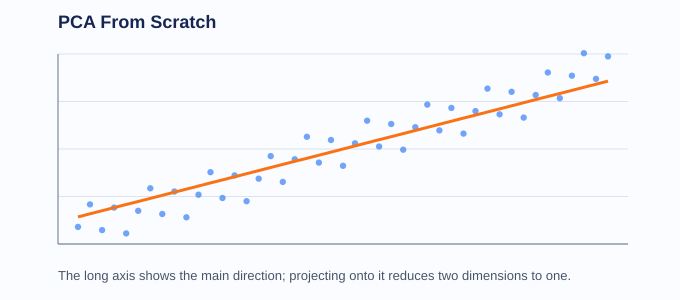

In [ ]:
# This cell displays the chart preview saved in the notebook.
